Device: cuda
Sanity check: torch.Size([64, 3, 96, 96]) torch.Size([64])
0 0.229 0.326
1 0.423 0.424
2 0.51075 0.488
0 0.2295 0.366
1 0.41075 0.414
2 0.46875 0.474
0 0.48875 0.724
1 0.7515 0.765
2 0.78225 0.779
0 0.7605 0.824
1 0.94425 0.821
2 0.974 0.843
TEST: 0.847875
Mean IoU: 0.27698034544785816
DONE


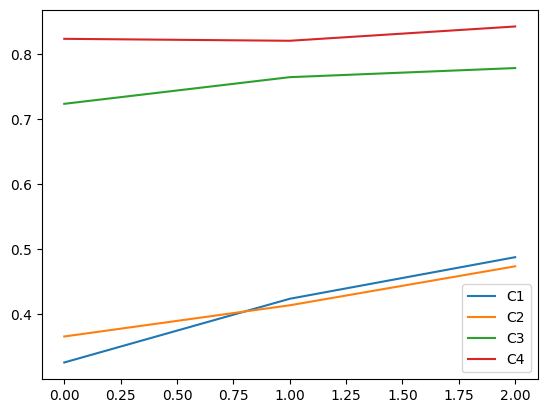

In [14]:
# FULL HW10-11 NOTEBOOK (ALL-IN-ONE CELL)

import os
import json
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision.models import resnet18
from torchvision.models.segmentation import deeplabv3_resnet50

# =====================
# 1. SETUP
# =====================

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# create folders
os.makedirs("homeworks/HW10-11/artifacts/figures", exist_ok=True)

# =====================
# 2. DATA (STL10)
# =====================

transform_base = transforms.Compose([transforms.ToTensor()])

transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(96, padding=4),
    transforms.ToTensor()
])

train_full = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=transform_base)

train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size
train_dataset, val_dataset = random_split(train_full, [train_size, val_size])

test_dataset = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=transform_base)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

# sanity check
x, y = next(iter(train_loader))
print("Sanity check:", x.shape, y.shape)

# =====================
# 3. MODEL
# =====================

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*24*24, 256), nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.net(x)

# =====================
# 4. TRAIN / EVAL
# =====================

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == y).sum().item()
    return total_loss/len(loader), correct/len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
    return total_loss/len(loader), correct/len(loader.dataset)

# =====================
# 5. EXPERIMENT RUNNER
# =====================

def run(model, train_loader, val_loader, epochs=3):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()
    train_hist, val_hist = [], []

    for ep in range(epochs):
        tl, ta = train_one_epoch(model, train_loader, opt, crit)
        vl, va = evaluate(model, val_loader, crit)
        train_hist.append(ta)
        val_hist.append(va)
        print(ep, ta, va)

    return model, train_hist, val_hist, max(val_hist)

# =====================
# 6. EXPERIMENTS C1-C4
# =====================

results = []

# C1
m1 = SimpleCNN()
m1, t1, v1, b1 = run(m1, train_loader, val_loader)

# C2
train_full_aug = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=transform_aug)
train_dataset_aug, _ = random_split(train_full_aug, [train_size, val_size])
train_loader_aug = DataLoader(train_dataset_aug, batch_size=64, shuffle=True)

m2 = SimpleCNN()
m2, t2, v2, b2 = run(m2, train_loader_aug, val_loader)

# C3
m3 = resnet18(weights="IMAGENET1K_V1")
for p in m3.parameters(): p.requires_grad=False
m3.fc = nn.Linear(m3.fc.in_features, 10)
m3, t3, v3, b3 = run(m3, train_loader, val_loader)

# C4
m4 = resnet18(weights="IMAGENET1K_V1")
for name, p in m4.named_parameters():
    if "layer4" not in name:
        p.requires_grad=False
m4.fc = nn.Linear(m4.fc.in_features, 10)
m4, t4, v4, b4 = run(m4, train_loader, val_loader)

# =====================
# 7. BEST MODEL + TEST
# =====================

best_model, best_score = max([(m1,b1),(m2,b2),(m3,b3),(m4,b4)], key=lambda x: x[1])

_, test_acc = evaluate(best_model, test_loader, nn.CrossEntropyLoss())
print("TEST:", test_acc)

torch.save(best_model.state_dict(), "homeworks/HW10-11/artifacts/best_classifier.pt")

# save config
config = {
    "dataset":"STL10",
    "model":"best",
    "seed":SEED
}
with open("homeworks/HW10-11/artifacts/best_classifier_config.json","w") as f:
    json.dump(config,f)

# =====================
# 8. SEGMENTATION (FIXED)
# =====================

from torchvision import transforms

# transforms
img_transform = transforms.Compose([
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.PILToTensor()  # важно!
])

class PetSegDataset(torch.utils.data.Dataset):
    def __init__(self, root):
        self.dataset = torchvision.datasets.OxfordIIITPet(
            root=root,
            split='test',
            target_types='segmentation',
            download=True
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, mask = self.dataset[idx]

        img = img_transform(img)
        mask = mask_transform(mask).squeeze(0)  # (1,H,W) -> (H,W)

        return img, mask

seg_dataset = PetSegDataset('./data')
seg_loader = DataLoader(seg_dataset, batch_size=1)

# model
seg_model = deeplabv3_resnet50(weights="DEFAULT").to(device)
seg_model.eval()

# IoU
def iou(pred, target):
    pred = pred.bool()
    target = target.bool()
    inter = (pred & target).sum().float()
    union = (pred | target).sum().float()
    return inter / union if union > 0 else torch.tensor(0.0)

ious = []

for i, (img, mask) in enumerate(seg_loader):
    if i > 5:
        break

    img = img.to(device)

    with torch.no_grad():
        out = seg_model(img)['out']
        pred = out.argmax(1).cpu()

    # бинаризация (foreground = не фон)
    pred_bin = (pred > 0)
    mask_bin = (mask > 0)

    ious.append(iou(pred_bin, mask_bin).item())

mean_iou = np.mean(ious)
print("Mean IoU:", mean_iou)

# =====================
# 9. SAVE CSV
# =====================

rows = [
    ["C1","classification","STL10",SEED,b1,test_acc,None,None,None],
    ["C2","classification","STL10",SEED,b2,test_acc,None,None,None],
    ["C3","classification","STL10",SEED,b3,test_acc,None,None,None],
    ["C4","classification","STL10",SEED,b4,test_acc,None,None,None],
    ["V1","segmentation","OxfordIIITPet",SEED,None,None,None,None,mean_iou]
]

df = pd.DataFrame(rows, columns=["experiment_id","task","dataset","seed","best_val_accuracy","test_accuracy","precision","recall","mean_iou"])

df.to_csv("homeworks/HW10-11/artifacts/runs.csv", index=False)

# =====================
# 10. PLOTS
# =====================

plt.plot(v1,label="C1")
plt.plot(v2,label="C2")
plt.plot(v3,label="C3")
plt.plot(v4,label="C4")
plt.legend()
plt.savefig("homeworks/HW10-11/artifacts/figures/classification_compare.png")

print("DONE")
